In [1]:
import numpy as np

import os
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter
import struct
import jax.numpy as jnp
import jax
from matplotlib.colors import Normalize
import seaborn
# import scienceplots
# plt.style.use(['science','notebook'])


jax.config.update("jax_enable_x64", True)

In [2]:
%%html
<style>
.jp-Notebook {
  --jp-notebook-max-width: 98%;
}</style>

In [3]:
pi = jnp.pi
N = 2**9

L = 2*pi
dx = L/N

nu = 1e-3
# ----------------------------------------
# Spectral Grid Setup (Memory-Efficient)
# ----------------------------------------


kx , ky , kz  = jnp.meshgrid(jnp.fft.fftfreq(N, dx)*(2*pi),jnp.fft.fftfreq(N, dx)*(2*pi), jnp.fft.rfftfreq(N, dx)*(2*pi),indexing= 'ij')

k_vec = jnp.stack([kx,ky,kz])

k_sq = (k_vec[0]**2 + k_vec[1]**2 + k_vec[2]**2)

k = jnp.sqrt(k_sq)


# ----------------------------------------
# Dealiasing and Projection Utilities
# ----------------------------------------


alias_mask = (abs(k_vec[0])<=N//3)*(abs(k_vec[1])<=N//3)*(abs(k_vec[2])<=N//3)

k_over_k_sq = jnp.where(k_sq == 0 , 0 ,  k_vec/k_sq)*alias_mask

kint = np.clip(np.round(k,0).astype(int),None,N//2)

normalize = jnp.where((k_vec[2]== 0) + (k_vec[2] == N//2) , 1/(N**6/L**3),2/(N**6/L**3))


shells = np.arange(-0.5, N//2 + 1 , 1.)
shells[0] = 0.
kvals = np.arange(0,N//2)

In [4]:
u_spec = np.fft.rfftn(np.load(f'/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Fractal_velocity_field_Real/Decimated_Fractal_D_2p80.npz')['u_real'], axes = (1,2,3))

In [5]:
u_spec.dtype

dtype('complex128')

In [6]:
print(np.fft.irfftn(np.sum(1j*k_vec*u_spec, 0)).max())

3.7001111635412305e-12


# QR Plot

In [7]:
Aij = np.zeros((3,3,N,N,N))
Sij = np.zeros((3,3,N,N,N))
wi =  np.zeros((3,N,N,N))

In [8]:
Aij[0,0] = np.fft.irfftn(1j * k_vec[0] * u_spec[0])
Aij[1,0] = np.fft.irfftn(1j * k_vec[1] * u_spec[0])
Aij[2,0] = np.fft.irfftn(1j * k_vec[2] * u_spec[0])

Aij[0,1] = np.fft.irfftn(1j * k_vec[0] * u_spec[1])
Aij[1,1] = np.fft.irfftn(1j * k_vec[1] * u_spec[1])
Aij[2,1] = np.fft.irfftn(1j * k_vec[2] * u_spec[1])

Aij[0,2] = np.fft.irfftn(1j * k_vec[0] * u_spec[2])
Aij[1,2] = np.fft.irfftn(1j * k_vec[1] * u_spec[2])
Aij[2,2] = np.fft.irfftn(1j * k_vec[2] * u_spec[2])


Sij[0,0] = Aij[0,0]
Sij[1,1] = Aij[1,1]
Sij[2,2] = Aij[2,2]

Sij[0,1] = 0.5*(Aij[0,1] + Aij[1,0])
Sij[0,2] = 0.5*(Aij[0,2] + Aij[2,0])
Sij[1,2] = 0.5*(Aij[1,2] + Aij[2,1])


Sij[1,0] = Sij[0,1]
Sij[2,0] = Sij[0,2]
Sij[2,1] = Sij[1,2]

wi[0] = Aij[1,2] - Aij[2,1] 
wi[1] = Aij[2,0] - Aij[0,2] 
wi[2] = Aij[0,1] - Aij[1,0] 

In [9]:
dissp_field = Sij[0,0]**2 + Sij[1,1]**2 + Sij[2,2]**2 + 2*(Sij[0,1]**2 + Sij[0,2]**2 + Sij[1,2]**2)

In [10]:
Q  = (-0.5)*np.einsum('abijk,baijk -> ijk',Aij,Aij)

Q = Q/(np.mean(dissp_field))

In [11]:
R = (-1/3)*np.einsum('abijk,bcijk, caijk -> ijk',Aij,Aij,Aij)

R = R/(np.mean(dissp_field)**(1.5))

In [12]:
Qf = Q.ravel()
Rf = R.ravel()


Qmin = -np.max(np.abs(Q))
Rmin =  -np.max(np.abs(R))
Qmax =   np.max(np.abs(Q))
Rmax =  np.max(np.abs(R))

bins = 200

H, Qedges, Redges = np.histogram2d(Qf, Rf,bins=bins,range=[[Qmin, Qmax], [Rmin, Rmax]],density=True)

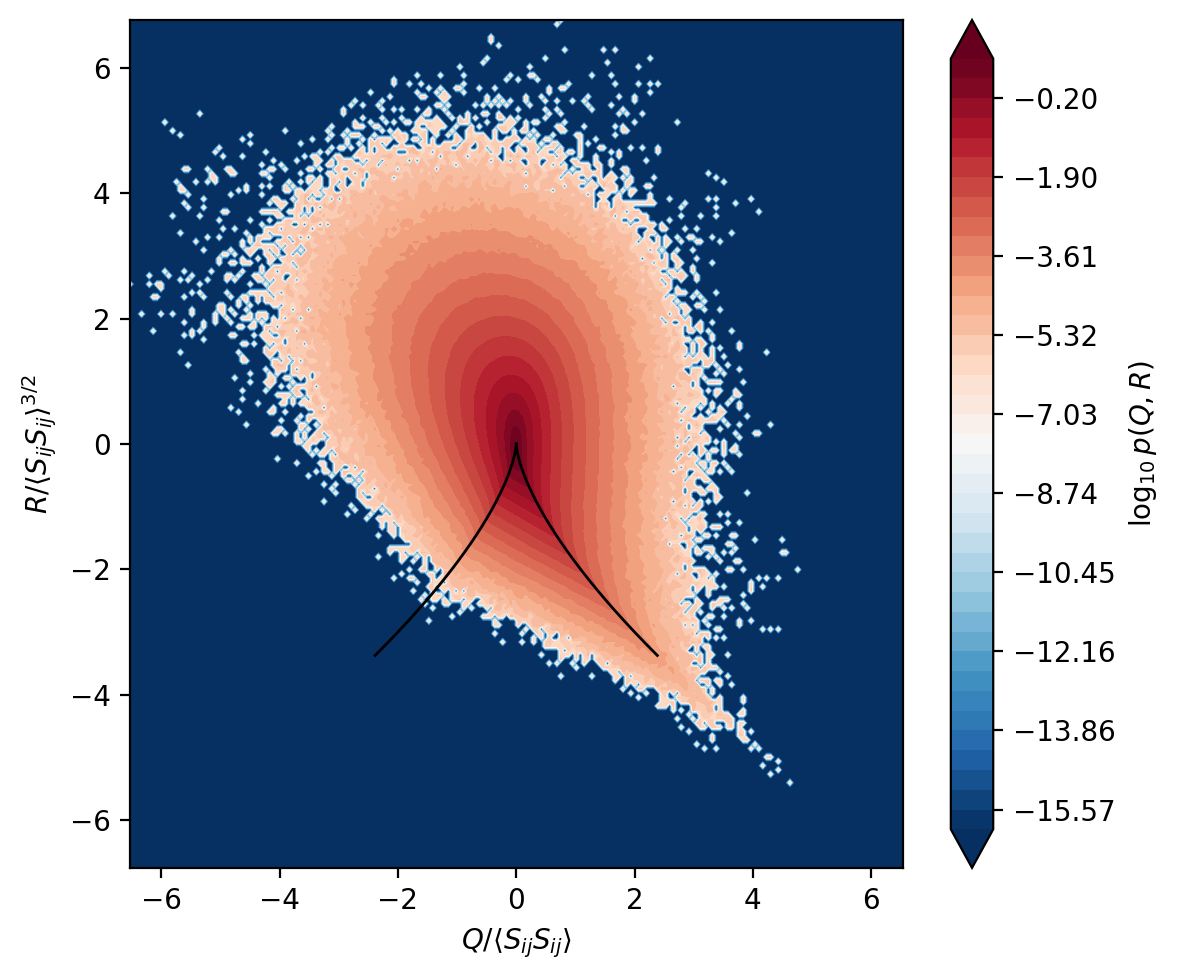

In [13]:
plt.figure(figsize=(6,5), dpi=200)

Qc = 0.5 * (Qedges[:-1] + Qedges[1:])
Rc = 0.5 * (Redges[:-1] + Redges[1:])

Z = np.log10(H.T + 1e-16)

levels = np.linspace(Z.min(), Z.max(), 40)

plt.contourf(Rc, Qc, Z.T, levels=levels,cmap='RdBu_r',extend='both')


# Vieillefosse tail (linear space!)
Qv = np.linspace(Qc.min(), 0.0, 500)
Rv = (2/(3*np.sqrt(3))) * (-Qv)**1.5


plt.plot( Rv[250:],  Qv[250:], 'k-', lw=1)
plt.plot(-Rv[250:],  Qv[250:], 'k-', lw=1)


plt.xlabel(r"$Q/\langle S_{ij}S_{ij}\rangle$")
plt.ylabel(r"$R/\langle S_{ij}S_{ij}\rangle^{3/2}$")

plt.colorbar(label=r"$\log_{10} p(Q,R)$")
plt.tight_layout()
plt.show()

In [14]:
np.savez("QR_D2p80_100percentile.npz", mass = H, Q = Qedges, R = Redges)

In [4]:
# Qedges_0p0 = np.load('QR_Data/QR_P0p0.npz')['Q']
# Redges_0p0= np.load('QR_Data/QR_P0p0.npz')['R']
# H_0p0 =  np.load('QR_Data/QR_P0p0.npz')['mass']


# Qedges_0p1 = np.load('QR_Data/QR_P0p1.npz')['Q']
# Redges_0p1 = np.load('QR_Data/QR_P0p1.npz')['R']
# H_0p1 =  np.load('QR_Data/QR_P0p1.npz')['mass']



# Qedges_0p3 = np.load('QR_Data/QR_P0p3.npz')['Q']
# Redges_0p3 = np.load('QR_Data/QR_P0p3.npz')['R']
# H_0p3=  np.load('QR_Data/QR_P0p3.npz')['mass']


# Qedges_0p5 = np.load('QR_Data/QR_P0p5.npz')['Q']
# Redges_0p5 = np.load('QR_Data/QR_P0p5.npz')['R']
# H_0p5 =  np.load('QR_Data/QR_P0p5.npz')['mass']



Qedges_0p0 = np.load('QR_Data/QR_P0p0_100percentile.npz')['Q']
Redges_0p0= np.load('QR_Data/QR_P0p0_100percentile.npz')['R']
H_0p0 =  np.load('QR_Data/QR_P0p0_100percentile.npz')['mass']


Qedges_0p1 = np.load('QR_Data/QR_P0p1_100percentile.npz')['Q']
Redges_0p1 = np.load('QR_Data/QR_P0p1_100percentile.npz')['R']
H_0p1 =  np.load('QR_Data/QR_P0p1_100percentile.npz')['mass']



Qedges_0p3 = np.load('QR_Data/QR_P0p3_100percentile.npz')['Q']
Redges_0p3 = np.load('QR_Data/QR_P0p3_100percentile.npz')['R']
H_0p3=  np.load('QR_Data/QR_P0p3_100percentile.npz')['mass']


Qedges_0p5 = np.load('QR_Data/QR_P0p5_100percentile.npz')['Q']
Redges_0p5 = np.load('QR_Data/QR_P0p5_100percentile.npz')['R']
H_0p5 =  np.load('QR_Data/QR_P0p5_100percentile.npz')['mass']


Qedges_D2p95 = np.load('QR_Data/QR_D2p95_100percentile.npz')['Q']
Redges_D2p95 = np.load('QR_Data/QR_D2p95_100percentile.npz')['R']
H_D2p95 =  np.load('QR_Data/QR_D2p95_100percentile.npz')['mass']



Qedges_D2p80 = np.load('QR_Data/QR_D2p80_100percentile.npz')['Q']
Redges_D2p80 = np.load('QR_Data/QR_D2p80_100percentile.npz')['R']
H_D2p80 =  np.load('QR_Data/QR_D2p80_100percentile.npz')['mass']



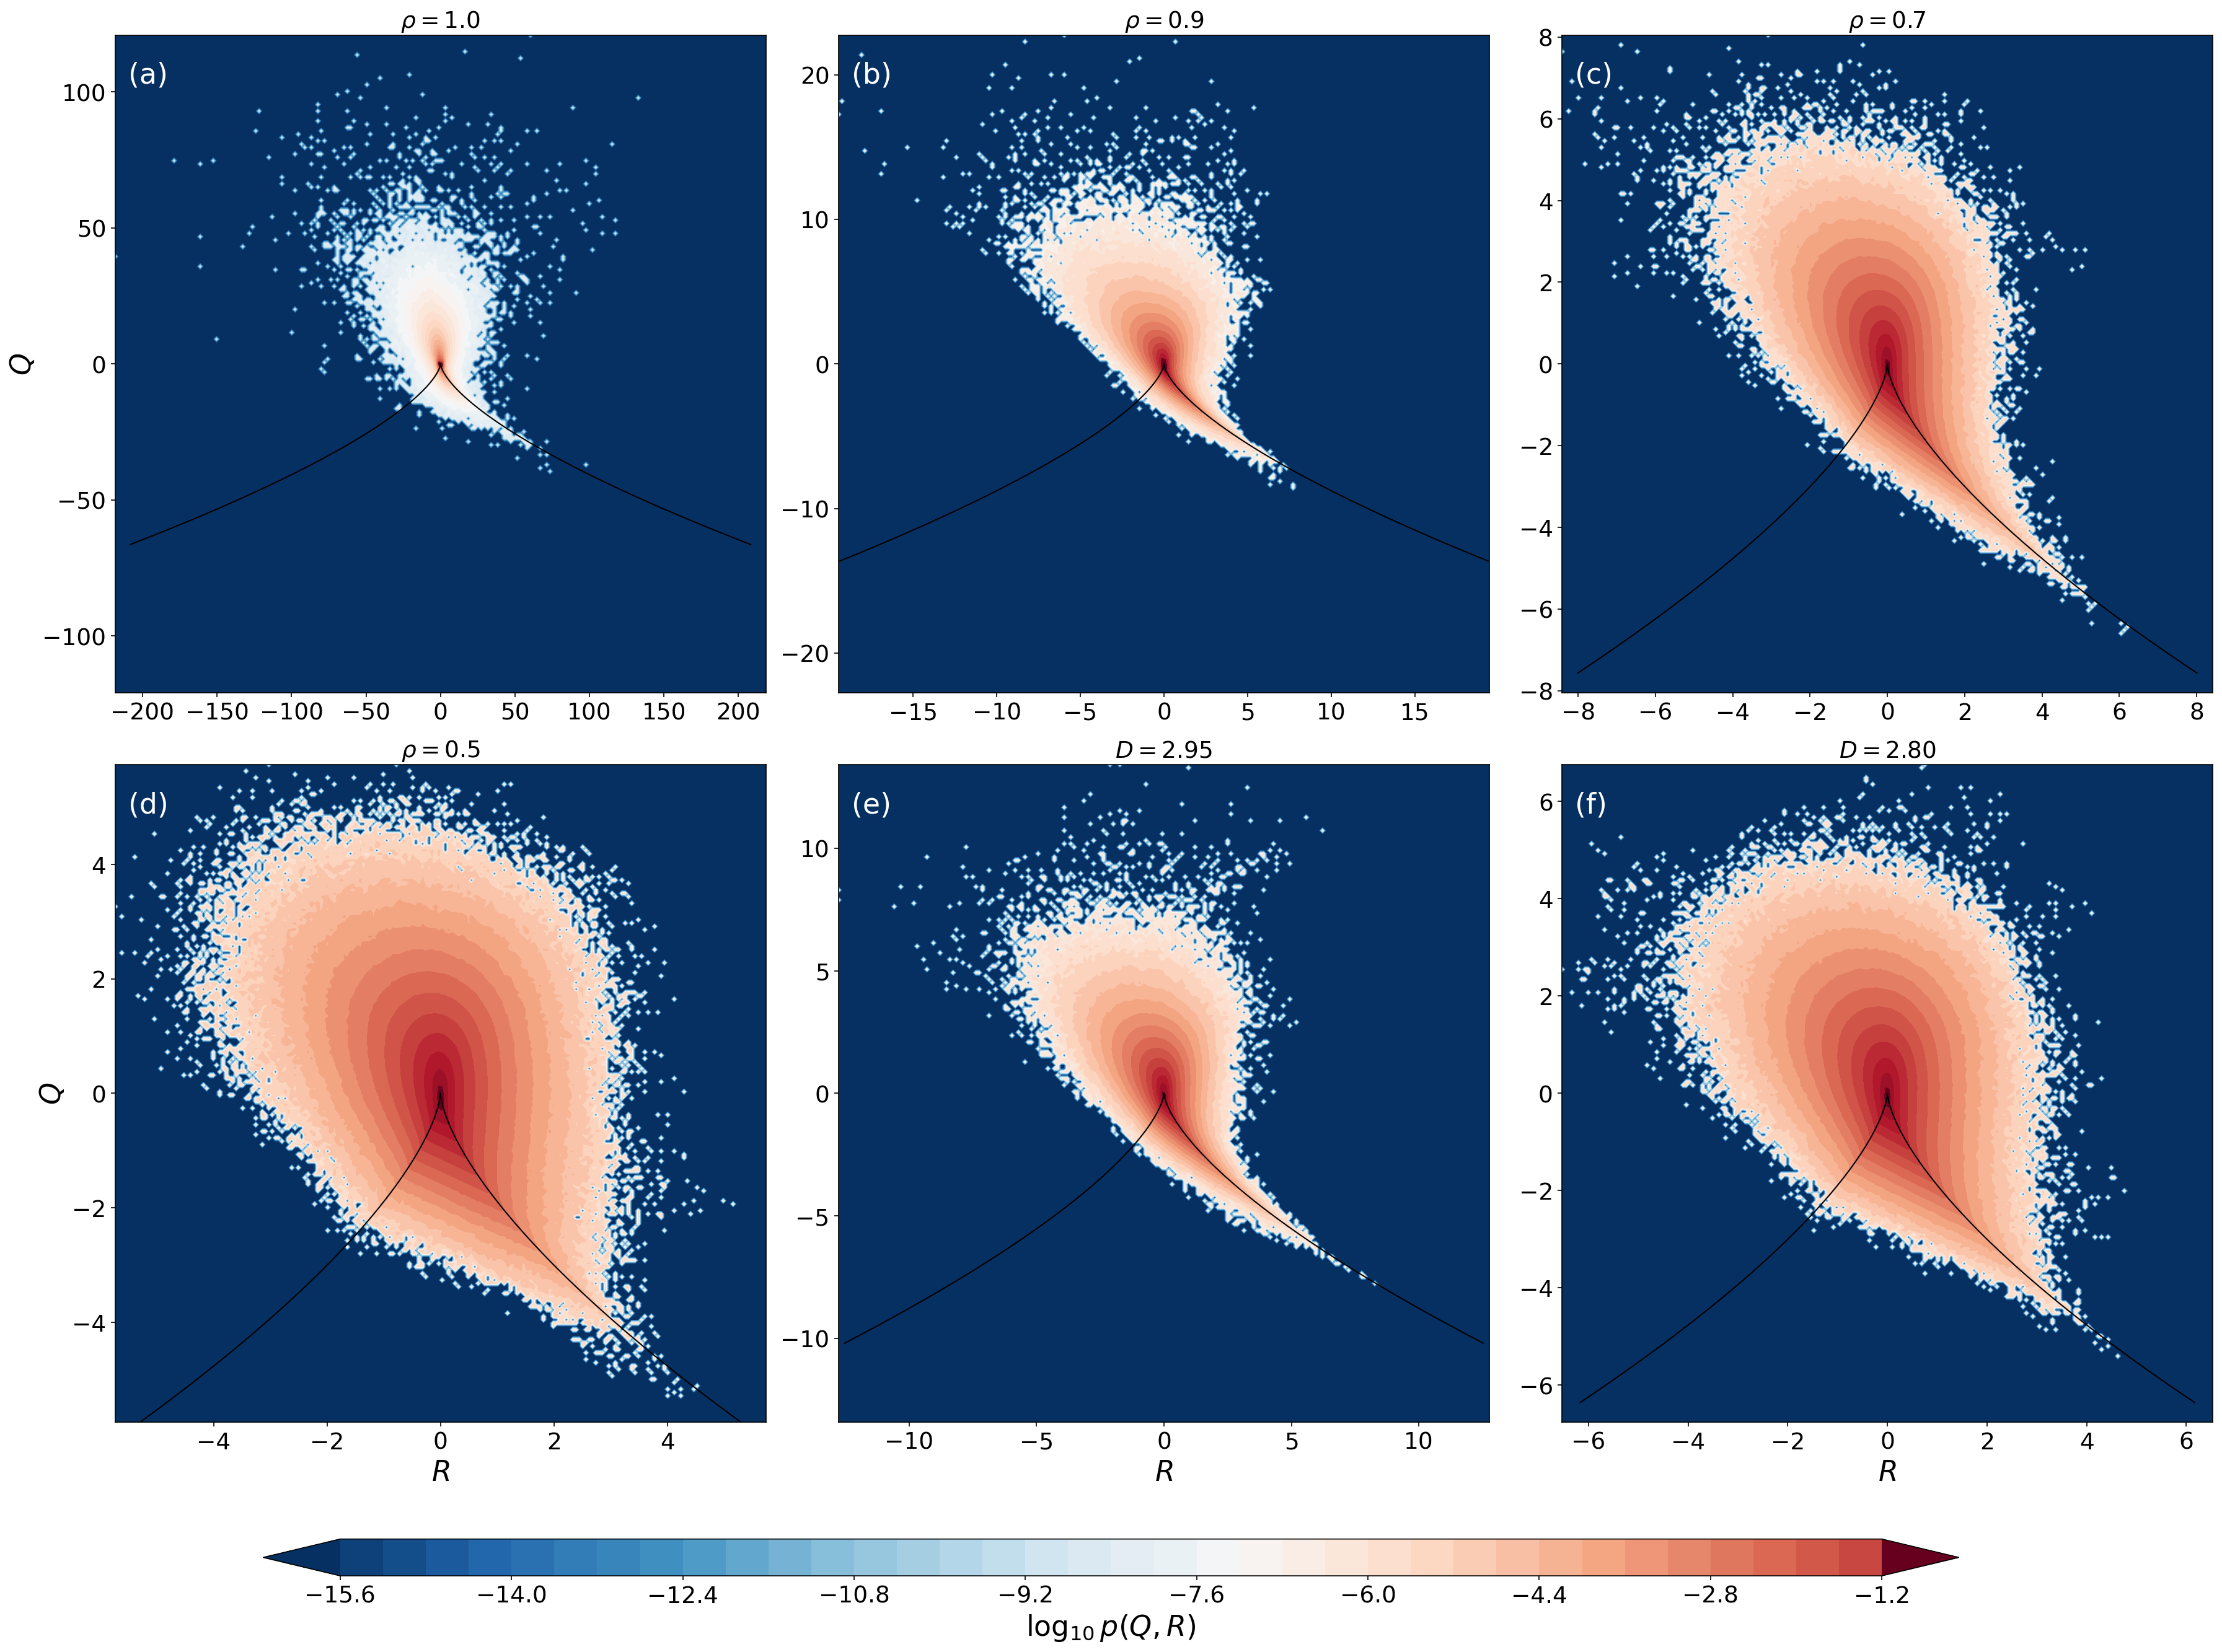

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import Normalize

# -----------------------------
# Matplotlib settings
# -----------------------------
mpl.rcParams.update({
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 20,
})

# -----------------------------
# Figure
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(24, 18), dpi=150)

# ============================================================
# ---- Compute all Z first (needed for global color scale) ----
# ============================================================

Qc0p0 = 0.5 * (Qedges_0p0[:-1] + Qedges_0p0[1:])
Rc0p0 = 0.5 * (Redges_0p0[:-1] + Redges_0p0[1:])
Z0p0 = np.log10(H_0p0.T + 1e-16)

Qc0p1 = 0.5 * (Qedges_0p1[:-1] + Qedges_0p1[1:])
Rc0p1 = 0.5 * (Redges_0p1[:-1] + Redges_0p1[1:])
Z0p1 = np.log10(H_0p1.T + 1e-16)

Qc0p3 = 0.5 * (Qedges_0p3[:-1] + Qedges_0p3[1:])
Rc0p3 = 0.5 * (Redges_0p3[:-1] + Redges_0p3[1:])
Z0p3 = np.log10(H_0p3.T + 1e-16)

Qc0p5 = 0.5 * (Qedges_0p5[:-1] + Qedges_0p5[1:])
Rc0p5 = 0.5 * (Redges_0p5[:-1] + Redges_0p5[1:])
Z0p5 = np.log10(H_0p5.T + 1e-16)

QcD2p95 = 0.5 * (Qedges_D2p95[:-1] + Qedges_D2p95[1:])
RcD2p95 = 0.5 * (Redges_D2p95[:-1] + Redges_D2p95[1:])
ZD2p95 = np.log10(H_D2p95.T + 1e-16)

QcD2p80 = 0.5 * (Qedges_D2p80[:-1] + Qedges_D2p80[1:])
RcD2p80 = 0.5 * (Redges_D2p80[:-1] + Redges_D2p80[1:])
ZD2p80 = np.log10(H_D2p80.T + 1e-16)

# -----------------------------
# Global color normalization
# -----------------------------
vmin = min(Z0p0.min(), Z0p1.min(), Z0p3.min(),
           Z0p5.min(), ZD2p95.min(), ZD2p80.min())

vmax = max(Z0p0.max(), Z0p1.max(), Z0p3.max(),
           Z0p5.max(), ZD2p95.max(), ZD2p80.max())

norm = Normalize(vmin=-16, vmax=1.5)

# ============================================================
# ------------------------- PLOTS -----------------------------
# ============================================================

# ---- (a)
cf = axes[0,0].contourf(Rc0p0, Qc0p0, Z0p0.T,
                        levels=40, cmap='RdBu_r',
                        norm=norm, extend='both')

Qv = np.linspace(Qc0p0.min(), 0.0, 500)
Rv = (2/(3*np.sqrt(3))) * (-Qv)**1.5
axes[0,0].plot(Rv[225:], Qv[225:], 'k-', lw=1)
axes[0,0].plot(-Rv[225:], Qv[225:], 'k-', lw=1)

# ---- (b)
axes[0,1].contourf(Rc0p1, Qc0p1, Z0p1.T,
                   levels=40, cmap='RdBu_r',
                   norm=norm, extend='both')

Qv = np.linspace(Qc0p1.min(), 0.0, 500)
Rv = (2/(3*np.sqrt(3))) * (-Qv)**1.5
axes[0,1].plot(Rv[200:], Qv[200:], 'k-', lw=1)
axes[0,1].plot(-Rv[200:], Qv[200:], 'k-', lw=1)

# ---- (c)
axes[0,2].contourf(Rc0p3, Qc0p3, Z0p3.T,
                   levels=40, cmap='RdBu_r',
                   norm=norm, extend='both')

Qv = np.linspace(Qc0p3.min(), 0.0, 500)
Rv = (2/(3*np.sqrt(3))) * (-Qv)**1.5
axes[0,2].plot(Rv[30:], Qv[30:], 'k-', lw=1)
axes[0,2].plot(-Rv[30:], Qv[30:], 'k-', lw=1)

# ---- (d)
axes[1,0].contourf(Rc0p5, Qc0p5, Z0p5.T,
                   levels=40, cmap='RdBu_r',
                   norm=norm, extend='both')

Qv = np.linspace(Qc0p5.min(), 0.0, 500)
Rv = (2/(3*np.sqrt(3))) * (-Qv)**1.5
axes[1,0].plot(Rv, Qv, 'k-', lw=1)
axes[1,0].plot(-Rv, Qv, 'k-', lw=1)

# ---- (e)
axes[1,1].contourf(RcD2p95, QcD2p95, ZD2p95.T,
                   levels=40, cmap='RdBu_r',
                   norm=norm, extend='both')

Qv = np.linspace(QcD2p95.min(), 0.0, 500)
Rv = (2/(3*np.sqrt(3))) * (-Qv)**1.5
axes[1,1].plot(Rv[120:], Qv[120:], 'k-', lw=1)
axes[1,1].plot(-Rv[120:], Qv[120:], 'k-', lw=1)

# ---- (f)
axes[1,2].contourf(RcD2p80, QcD2p80, ZD2p80.T,
                   levels=40, cmap='RdBu_r',
                   norm=norm, extend='both')

Qv = np.linspace(QcD2p80.min(), 0.0, 500)
Rv = (2/(3*np.sqrt(3))) * (-Qv)**1.5
axes[1,2].plot(Rv[30:], Qv[30:], 'k-', lw=1)
axes[1,2].plot(-Rv[30:], Qv[30:], 'k-', lw=1)

# ============================================================
# -------------------- AXES LABELS ----------------------------
# ============================================================

for ax in axes[:, 0]:
    ax.set_ylabel(r"$Q$", fontsize=22)

for ax in axes[1, :]:
    ax.set_xlabel(r"$R$", fontsize=22)

panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
for ax, label in zip(axes.flat, panel_labels):
    ax.text(0.02, 0.96, label, transform=ax.transAxes,
            fontsize=22, va='top', ha='left', color='white')

titles = [
    r"$\rho = 1.0$", r"$\rho = 0.9$", r"$\rho = 0.7$",
    r"$\rho = 0.5$", r"$D = 2.95$", r"$D = 2.80$"
]
for ax, title in zip(axes.flat, titles):
    ax.set_title(title, fontsize=18, pad=6)

# ============================================================
# ---------------- COMMON COLORBAR ----------------------------
# ============================================================

# cax = fig.add_axes([0.15, 0.03, 0.70, 0.025])

# cbar = fig.colorbar(
#     cf,
#     cax=cax,
#     orientation='horizontal'
# )
# cbar.ax.tick_params(labelsize=18)


# 3. let matplotlib arrange subplots
plt.tight_layout(rect=[0, 0.10, 1, 1])

# 4. add colorbar manually
cax = fig.add_axes([0.12, 0.055, 0.76, 0.022])
cbar = fig.colorbar(cf, cax=cax, orientation='horizontal')
cbar.set_label(r"$\log_{10} p(Q,R)$", fontsize=22)




plt.savefig("100_percentile_QR_init_plot.png", dpi=300)




plt.show()

# PDF for Q and R

In [70]:
# bins_Q = np.linspace(np.min(Qf), np.max(Qf), 100 )
# PDF_Q , bins_Q = np.histogram(Qf, bins = bins_Q, density = True)
# bin_center = 0.5*(bins_Q[0:-1] + bins_Q[1:])

In [71]:
# bins_R = np.linspace(np.min(Rf), np.max(Rf), 100 )
# PDF_R , bins_R = np.histogram(Rf, bins = bins_R, density = True)
# bin_center = 0.5*(PDF_R[0:-1] + PDF_R[1:])

In [72]:
# np.savez("QR_PDF_0p5.npz", bins_R = bins_R, bins_Q = bins_Q, PDF_R = PDF_R, PDF_Q = PDF_Q)

In [5]:
Qedges_0p0 = np.load('QR_Data/QR_PDF_0p0.npz')['bins_Q']
Redges_0p0= np.load('QR_Data/QR_PDF_0p0.npz')['bins_R']
Q_0p0 =  np.load('QR_Data/QR_PDF_0p0.npz')['PDF_Q']
R_0p0 =  np.load('QR_Data/QR_PDF_0p0.npz')['PDF_R']


Qedges_0p1 = np.load('QR_Data/QR_PDF_0p1.npz')['bins_Q']
Redges_0p1= np.load('QR_Data/QR_PDF_0p1.npz')['bins_R']
Q_0p1 =  np.load('QR_Data/QR_PDF_0p1.npz')['PDF_Q']
R_0p1 =  np.load('QR_Data/QR_PDF_0p1.npz')['PDF_R']



Qedges_0p3 = np.load('QR_Data/QR_PDF_0p3.npz')['bins_Q']
Redges_0p3= np.load('QR_Data/QR_PDF_0p3.npz')['bins_R']
Q_0p3 =  np.load('QR_Data/QR_PDF_0p3.npz')['PDF_Q']
R_0p3 =  np.load('QR_Data/QR_PDF_0p3.npz')['PDF_R']


Qedges_0p5 = np.load('QR_Data/QR_PDF_0p5.npz')['bins_Q']
Redges_0p5= np.load('QR_Data/QR_PDF_0p5.npz')['bins_R']
Q_0p5 =  np.load('QR_Data/QR_PDF_0p5.npz')['PDF_Q']
R_0p5 =  np.load('QR_Data/QR_PDF_0p5.npz')['PDF_R']

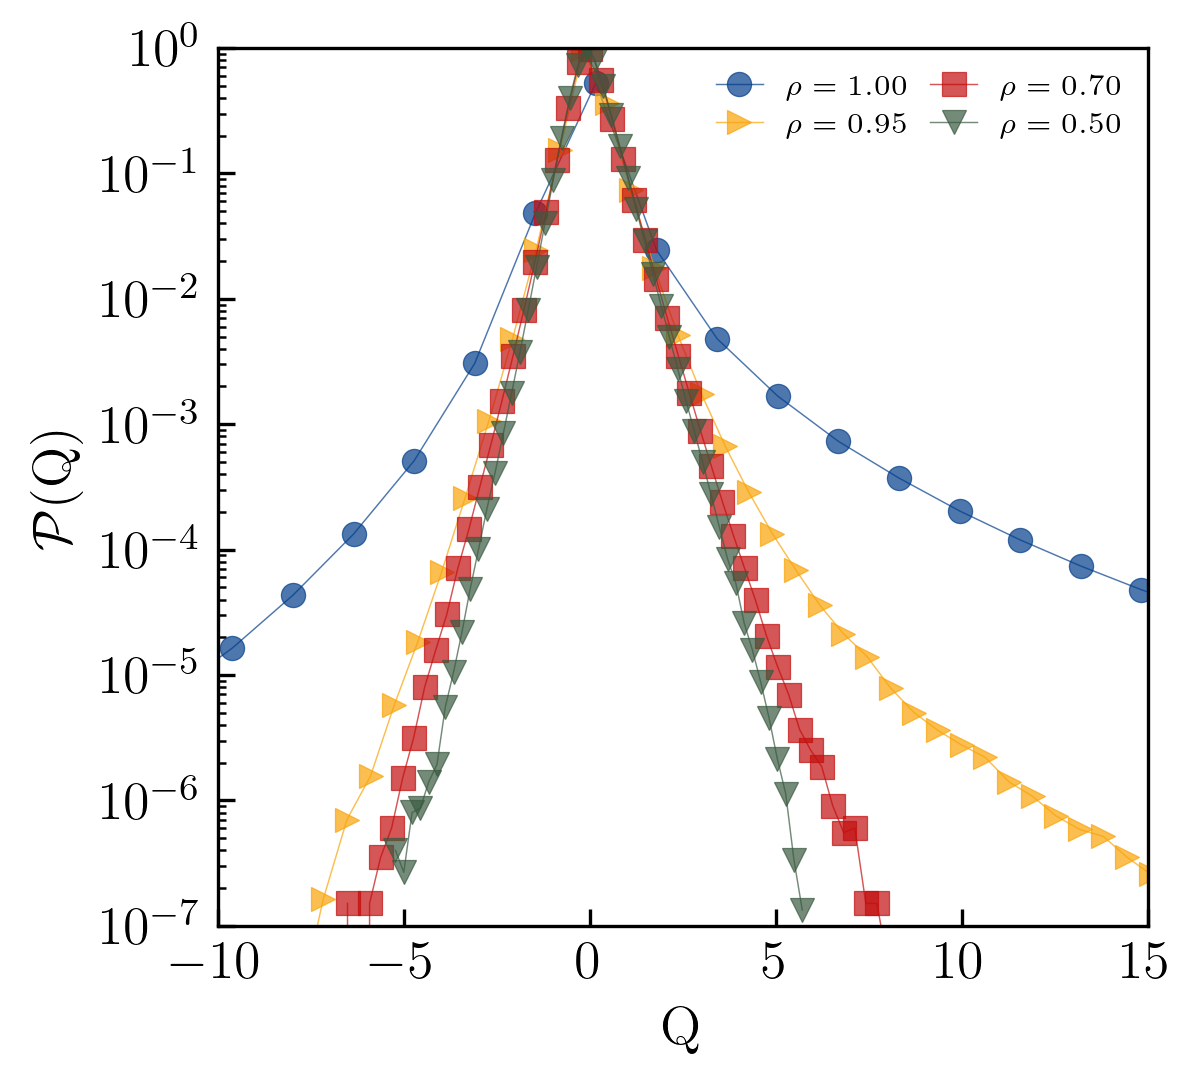

In [6]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 13,
    "axes.labelsize": 13,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "legend.frameon": False,
})

plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"

import seaborn as sns

colors = ["#023e8a","#0096c7","#faa307","#ff4800","#c30e0e","#3a5a40"]
markers = ["o", ">","s","v", "D","^"]
alphas=[1,0.95,0.7,0.5]
Dims = [2.95, 2.80]


fig,ax = plt.subplots(figsize=(4.0, 3.8), dpi=300)
# -----------------------------
# Main plot
# -----------------------------



ax.semilogy(0.5*(Qedges_0p0[1:]+Qedges_0p0[:-1]) , Q_0p0,marker=markers[0],markersize=5.8,ls='-',alpha=0.7,lw=0.35,color=colors[0],markeredgewidth=0.3,label=fr"$\rho = {alphas[0]:.2f}$",)
ax.semilogy(0.5*(Qedges_0p1[1:]+Qedges_0p1[:-1])[::2] , Q_0p1[::2],marker=markers[1],markersize=5.8,ls='-',alpha=0.7,lw=0.35,color=colors[2],markeredgewidth=0.3,label=fr"$\rho = {alphas[1]:.2f}$",)
ax.semilogy(0.5*(Qedges_0p3[1:]+Qedges_0p3[:-1])[::2] , Q_0p3[::2],marker=markers[2],markersize=5.8,ls='-',alpha=0.7,lw=0.35,color=colors[4],markeredgewidth=0.3,label=fr"$\rho = {alphas[2]:.2f}$",)
ax.semilogy(0.5*(Qedges_0p5[1:]+Qedges_0p5[:-1])[::2] , Q_0p5[::2],marker=markers[3],markersize=5.8,ls='-',alpha=0.7,lw=0.35,color=colors[5],markeredgewidth=0.3,label=fr"$\rho = {alphas[3]:.2f}$",)

ax.set_xlabel(r"Q")
ax.set_ylabel(r"$\mathcal{P}$(Q)")

ax.set_xlim(-10,15)
ax.set_ylim(1e-7,1)

# # -----------------------------
# # Legend
# # -----------------------------
ax.legend(
    loc="upper right",
    ncol=2,                
    handlelength=1.6,
    columnspacing=0.8,
    borderpad=0.4,
    labelspacing=0.4,
    prop={"size": 7},
)



# plt.savefig(
#     "dissp_distribution.png",
#     dpi=300,
#     bbox_inches="tight",
#     pad_inches=0
# )

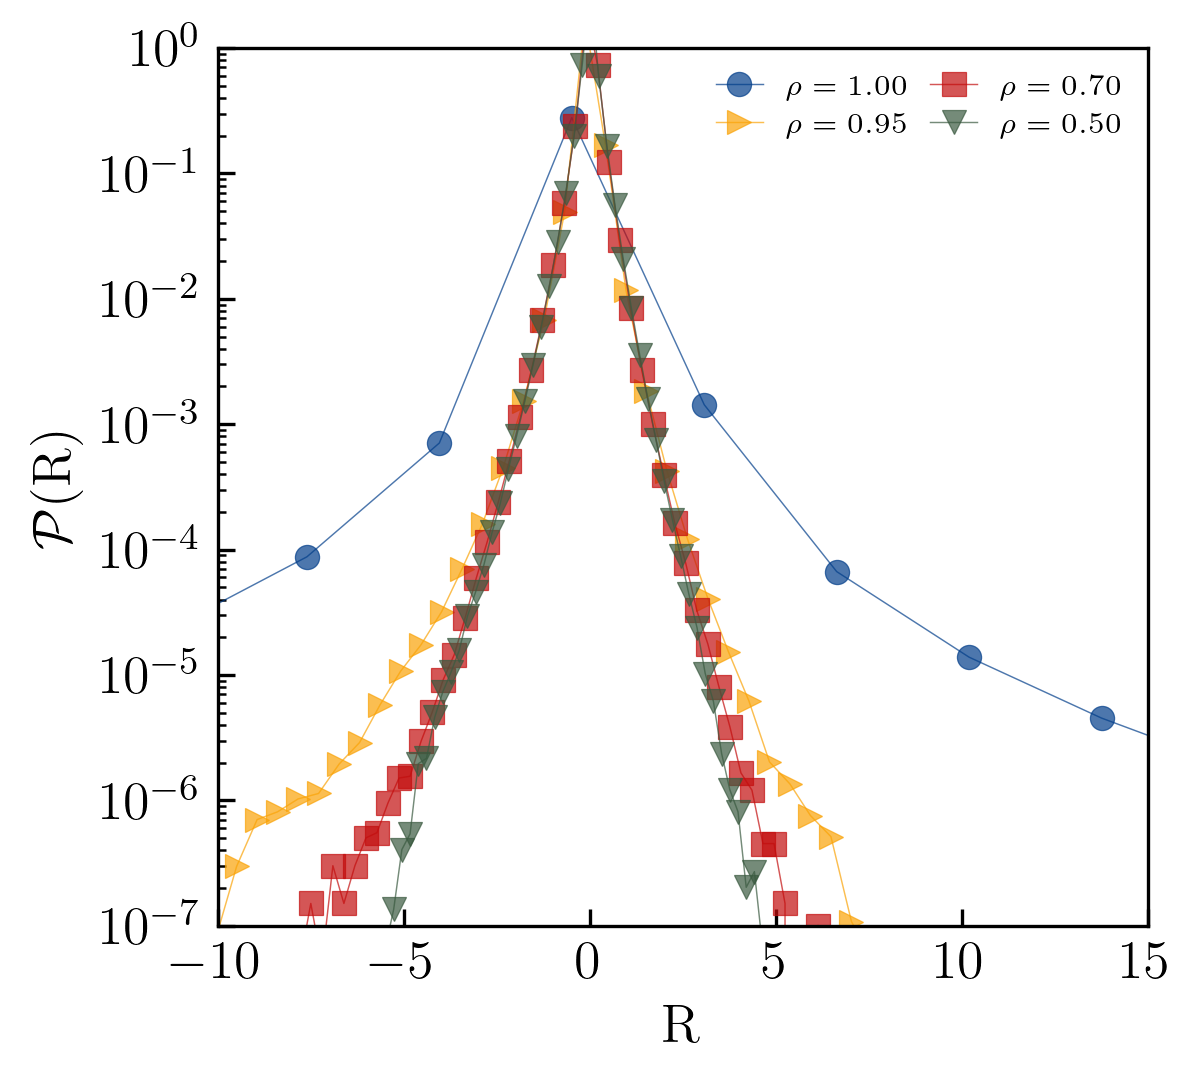

In [22]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 13,
    "axes.labelsize": 13,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "legend.frameon": False,
})

plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"

import seaborn as sns

colors = ["#023e8a","#0096c7","#faa307","#ff4800","#c30e0e","#3a5a40"]
markers = ["o", ">","s","v", "D","^"]
alphas=[1,0.95,0.7,0.5]
Dims = [2.95, 2.80]


fig,ax = plt.subplots(figsize=(4.0, 3.8), dpi=300)
# -----------------------------
# Main plot
# -----------------------------



ax.semilogy(0.5*(Redges_0p0[1:]+Redges_0p0[:-1]) , R_0p0,marker=markers[0],markersize=5.8,ls='-',alpha=0.7,lw=0.35,color=colors[0],markeredgewidth=0.3,label=fr"$\rho = {alphas[0]:.2f}$",)
ax.semilogy(0.5*(Redges_0p1[1:]+Redges_0p1[:-1])[::2] , R_0p1[::2],marker=markers[1],markersize=5.8,ls='-',alpha=0.7,lw=0.35,color=colors[2],markeredgewidth=0.3,label=fr"$\rho = {alphas[1]:.2f}$",)
ax.semilogy(0.5*(Redges_0p3[1:]+Redges_0p3[:-1])[::2] , R_0p3[::2],marker=markers[2],markersize=5.8,ls='-',alpha=0.7,lw=0.35,color=colors[4],markeredgewidth=0.3,label=fr"$\rho = {alphas[2]:.2f}$",)
ax.semilogy(0.5*(Redges_0p5[1:]+Redges_0p5[:-1])[::2] , R_0p5[::2],marker=markers[3],markersize=5.8,ls='-',alpha=0.7,lw=0.35,color=colors[5],markeredgewidth=0.3,label=fr"$\rho = {alphas[3]:.2f}$",)


ax.set_xlim(-10,15)
ax.set_ylim(1e-7,1)



ax.set_xlabel(r"R")
ax.set_ylabel(r"$\mathcal{P}$(R)")

# # -----------------------------
# # Legend
# # -----------------------------
ax.legend(
    loc="upper right",
    ncol=2,                
    handlelength=1.6,
    columnspacing=0.8,
    borderpad=0.4,
    labelspacing=0.4,
    prop={"size": 7},
)



# plt.savefig(
#     "dissp_distribution.png",
#     dpi=300,
#     bbox_inches="tight",
#     pad_inches=0
# )

# PDF for Vortex Production and Vortex Streching terms

In [11]:
wsw = np.einsum('aijk,abijk, bijk -> ijk',wi,Sij,wi)
wsw = wsw/np.mean(dissp_field)**(3/2)

In [18]:
N_bins = 150

bins_1 = np.linspace(wsw.min(),wsw.max(), N_bins, endpoint = False)


# bins_2 = np.linspace(-2,0,25,endpoint = False)
# bins_3 = np.linspace(0,2,50,endpoint = False)
# bins_4 = np.linspace(50, wsw.max(),10, endpoint = True)

# bins_wsw = np.concatenate((bins_1,bins_2,bins_3,bins_4))

PDF_wsw, bins_wsw = np.histogram(wsw, bins =bins_1, density=True)
bin_center_wsw = 0.5 * (bins_wsw[:-1] + bins_wsw[1:])

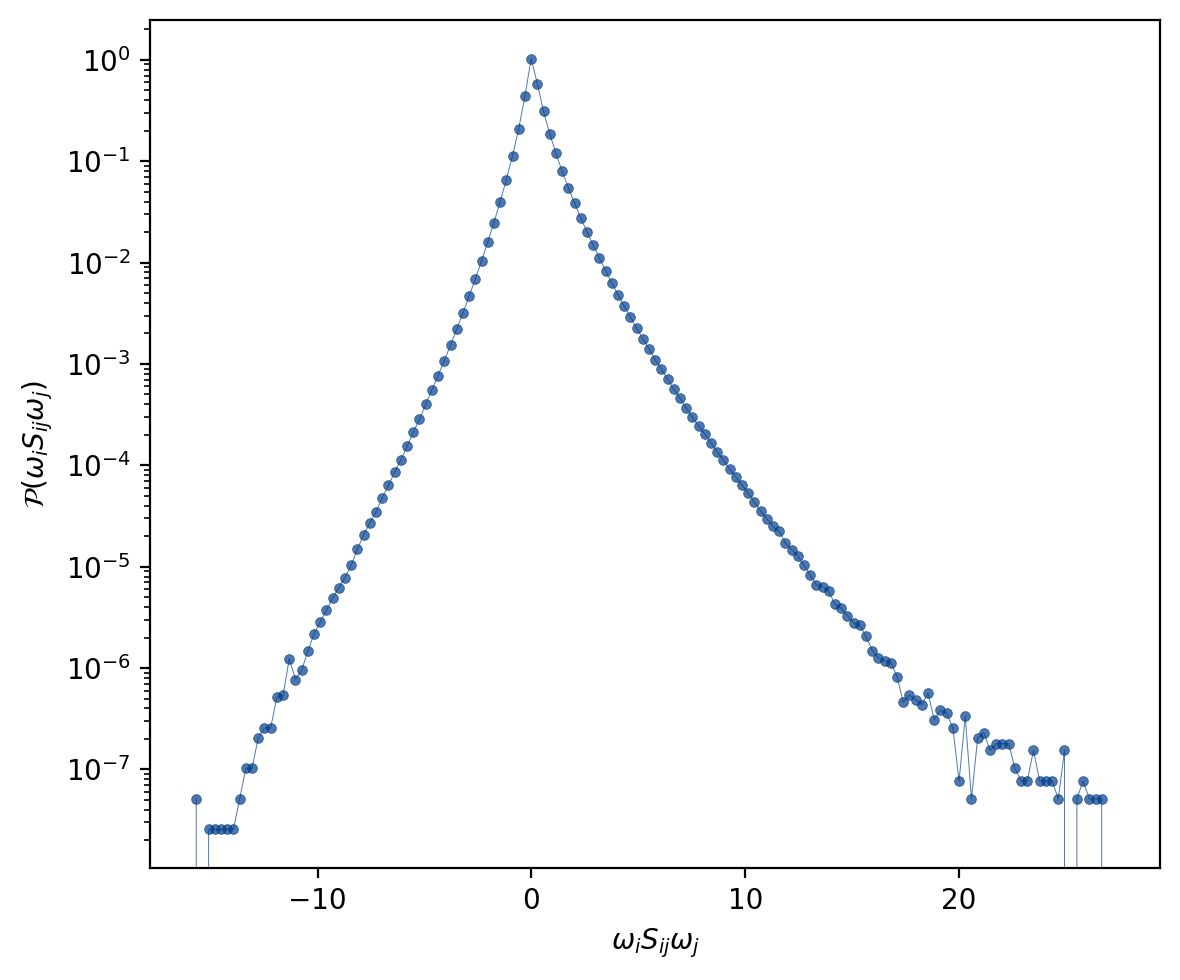

In [19]:
colors = ["#023e8a","#0096c7","#faa307","#ff4800","#c30e0e","#3a5a40"]
markers = ["o", ">","s","v", "D","^"]
alphas=[1,0.95,0.7,0.5]
Dims = [2.95, 2.80]


plt.figure(figsize=(6, 5), dpi=200)

plt.semilogy(bin_center_wsw , PDF_wsw ,marker=markers[0],markersize=3.5,ls='-',alpha=0.7,lw=0.35,color=colors[0],markeredgewidth=0.3,label=fr"$\rho = {alphas[0]:.2f}$",)

plt.yscale("log")

plt.xlabel(r"$\omega_iS_{ij}\omega_j$")
plt.ylabel(r"$\mathcal{P}(\omega_iS_{ij}\omega_j)$")

plt.tight_layout()
plt.show()

In [20]:
sss = -(4/3)*np.einsum('abijk,bcijk, caijk -> ijk',Sij,Sij,Sij)

sss = sss/np.mean(dissp_field)**(3/2)

In [21]:
N_bins = 100

bins_1 = np.linspace(sss.min(),sss.max(), N_bins, endpoint = False)


# bins_2 = np.linspace(-5,0,30,endpoint = False)
# bins_3 = np.linspace(0,5,20,endpoint = False)


# bins_4 = np.linspace(5, sss.max(),N_bins, endpoint = True)

# bins_sss = np.concatenate((bins_1,bins_2,bins_3,bins_4))

PDF_sss, bins_sss = np.histogram(sss, bins=bins_1, density=True)
bin_center_sss = 0.5 * (bins_sss[:-1] + bins_sss[1:])

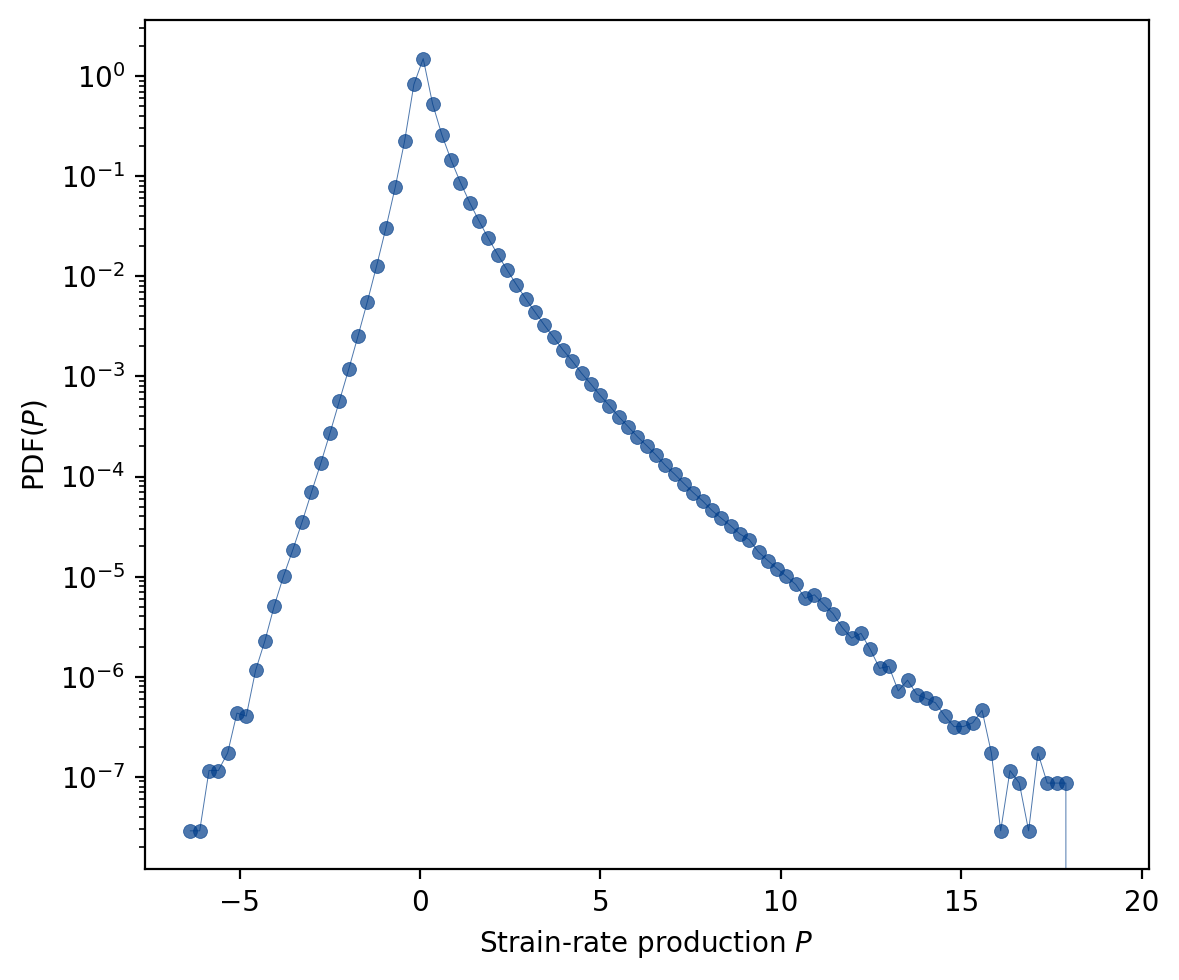

In [22]:

colors = ["#023e8a","#0096c7","#faa307","#ff4800","#c30e0e","#3a5a40"]
markers = ["o", ">","s","v", "D","^"]
alphas=[1,0.95,0.7,0.5]
Dims = [2.95, 2.80]


plt.figure(figsize=(6, 5), dpi=200)

plt.semilogy(bin_center_sss , PDF_sss ,marker=markers[0],markersize=5,ls='-',alpha=0.7,lw=0.35,color=colors[0],markeredgewidth=0.3,label=fr"$\rho = {alphas[0]:.2f}$",)

plt.yscale("log")

plt.xlabel(r"Strain-rate production $P$")
plt.ylabel(r"PDF$(P)$")

plt.tight_layout()
plt.show()

In [23]:
np.savez("wsw_sss_PDF_D2p80.npz", bins_sss = bin_center_sss, bins_wsw = bin_center_wsw, PDF_sss = PDF_sss, PDF_wsw = PDF_wsw)

In [25]:
wswedges_0p0 = np.load('QR_Data/wsw_sss_PDF_0p0.npz')['bins_wsw']
sssedges_0p0= np.load('QR_Data/wsw_sss_PDF_0p0.npz')['bins_sss']
wsw_0p0 =  np.load('QR_Data/wsw_sss_PDF_0p0.npz')['PDF_wsw']
sss_0p0 =  np.load('QR_Data/wsw_sss_PDF_0p0.npz')['PDF_sss']


wswedges_0p1 = np.load('QR_Data/wsw_sss_PDF_0p1.npz')['bins_wsw']
sssedges_0p1= np.load('QR_Data/wsw_sss_PDF_0p1.npz')['bins_sss']
wsw_0p1 =  np.load('QR_Data/wsw_sss_PDF_0p1.npz')['PDF_wsw']
sss_0p1 =  np.load('QR_Data/wsw_sss_PDF_0p1.npz')['PDF_sss']




wswedges_0p3 = np.load('QR_Data/wsw_sss_PDF_0p3.npz')['bins_wsw']
sssedges_0p3= np.load('QR_Data/wsw_sss_PDF_0p3.npz')['bins_sss']
wsw_0p3 =  np.load('QR_Data/wsw_sss_PDF_0p3.npz')['PDF_wsw']
sss_0p3 =  np.load('QR_Data/wsw_sss_PDF_0p3.npz')['PDF_sss']





wswedges_0p5 = np.load('QR_Data/wsw_sss_PDF_0p5.npz')['bins_wsw']
sssedges_0p5= np.load('QR_Data/wsw_sss_PDF_0p5.npz')['bins_sss']
wsw_0p5 =  np.load('QR_Data/wsw_sss_PDF_0p5.npz')['PDF_wsw']
sss_0p5 =  np.load('QR_Data/wsw_sss_PDF_0p5.npz')['PDF_sss']





wswedges_D2p95 = np.load('QR_Data/wsw_sss_PDF_D2p95.npz')['bins_wsw']
sssedges_D2p95= np.load('QR_Data/wsw_sss_PDF_D2p95.npz')['bins_sss']
wsw_D2p95 =  np.load('QR_Data/wsw_sss_PDF_D2p95.npz')['PDF_wsw']
sss_D2p95 =  np.load('QR_Data/wsw_sss_PDF_D2p95.npz')['PDF_sss']


wswedges_D2p80 = np.load('QR_Data/wsw_sss_PDF_D2p80.npz')['bins_wsw']
sssedges_D2p80= np.load('QR_Data/wsw_sss_PDF_D2p80.npz')['bins_sss']
wsw_D2p80 =  np.load('QR_Data/wsw_sss_PDF_D2p80.npz')['PDF_wsw']
sss_D2p80 =  np.load('QR_Data/wsw_sss_PDF_D2p80.npz')['PDF_sss']


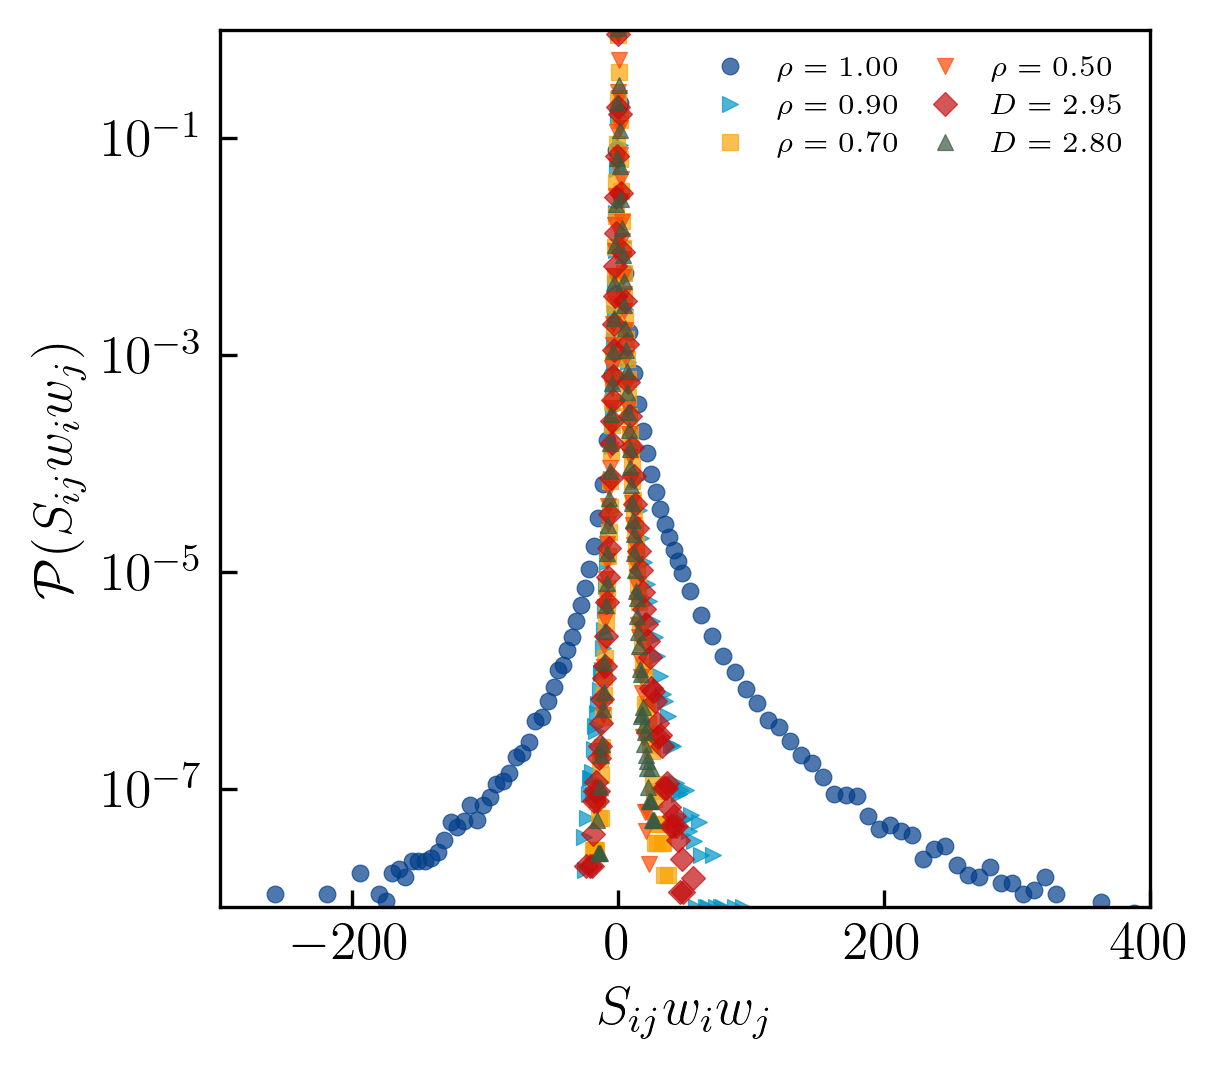

In [28]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 13,
    "axes.labelsize": 13,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "legend.frameon": False,
})

plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"

import seaborn as sns

colors = ["#023e8a","#0096c7","#faa307","#ff4800","#c30e0e","#3a5a40"]
markers = ["o", ">","s","v", "D","^"]
alphas=[1,0.9,0.7,0.5]
Dims = [2.95, 2.80]


fig,ax = plt.subplots(figsize=(4.0, 3.8), dpi=300)
# -----------------------------
# Main plot
# -----------------------------



ax.semilogy(
    wswedges_0p0, wsw_0p0,
    marker=markers[0],
    linestyle="None",
    markersize=4,
    alpha=0.7,
    color=colors[0],
    markeredgewidth=0.3,
    label=fr"$\rho = {alphas[0]:.2f}$",
)

ax.semilogy(
    wswedges_0p1[::2], wsw_0p1[::2],
    marker=markers[1],
    linestyle="None",
    markersize=4,
    alpha=0.7,
    color=colors[1],
    markeredgewidth=0.3,
    label=fr"$\rho = {alphas[1]:.2f}$",
)

ax.semilogy(
    wswedges_0p3[::2], wsw_0p3[::2],
    marker=markers[2],
    linestyle="None",
    markersize=4,
    alpha=0.7,
    color=colors[2],
    markeredgewidth=0.3,
    label=fr"$\rho = {alphas[2]:.2f}$",
)

ax.semilogy(
    wswedges_0p5[::2], wsw_0p5[::2],
    marker=markers[3],
    linestyle="None",
    markersize=4,
    alpha=0.7,
    color=colors[3],
    markeredgewidth=0.3,
    label=fr"$\rho = {alphas[3]:.2f}$",
)



ax.semilogy(
    wswedges_D2p95[::2], wsw_D2p95[::2],
    marker=markers[4],
    linestyle="None",
    markersize=4,
    alpha=0.7,
    color=colors[4],
    markeredgewidth=0.3,
    label=fr"$D = 2.95$",
)



ax.semilogy(
    wswedges_D2p80[::2], wsw_D2p80[::2],
    marker=markers[5],
    linestyle="None",
    markersize=4,
    alpha=0.7,
    color=colors[5],
    markeredgewidth=0.3,
    label=fr"$D = 2.80$",
)




ax.set_xlabel(r"$S_{ij}w_iw_j$")
ax.set_ylabel(r"$\mathcal{P}(S_{ij}w_iw_j)$")

ax.set_xlim(-300,400)
ax.set_ylim(8e-9,1)

# # -----------------------------
# # Legend
# # -----------------------------
ax.legend(
    loc="upper right",
    ncol=2,                
    handlelength=1.6,
    columnspacing=0.8,
    borderpad=0.4,
    labelspacing=0.4,
    prop={"size": 7},
)



# plt.savefig(
#     "Vorticity_prod.png",
#     dpi=300,
#     bbox_inches="tight",
#     pad_inches=0
# )

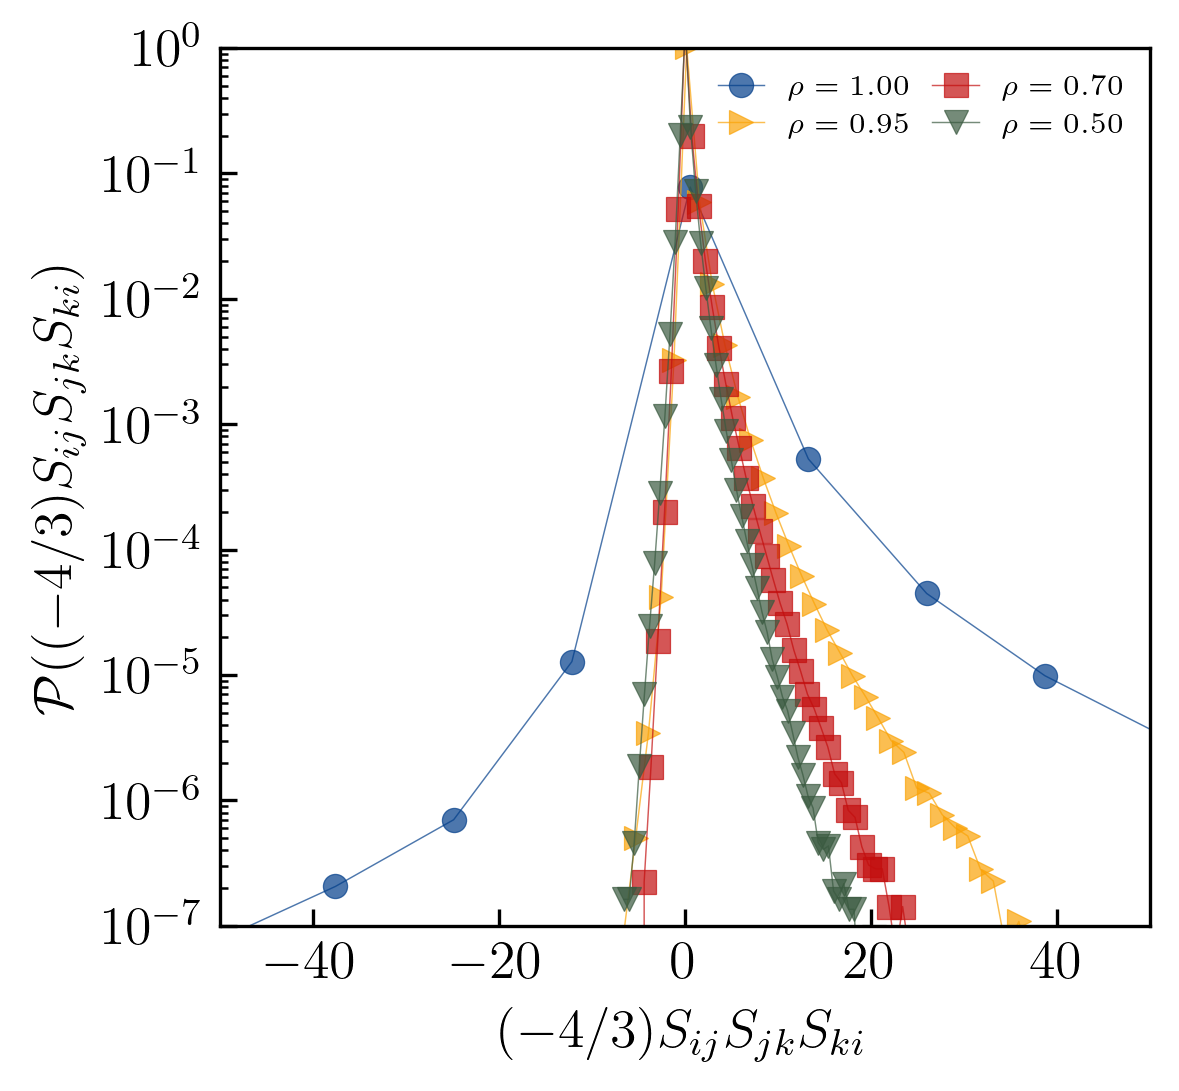

In [37]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 13,
    "axes.labelsize": 13,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "legend.frameon": False,
})

plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"

import seaborn as sns

colors = ["#023e8a","#0096c7","#faa307","#ff4800","#c30e0e","#3a5a40"]
markers = ["o", ">","s","v", "D","^"]
alphas=[1,0.95,0.7,0.5]
Dims = [2.95, 2.80]


fig,ax = plt.subplots(figsize=(4.0, 3.8), dpi=300)
# -----------------------------
# Main plot
# -----------------------------



ax.semilogy(SSSedges_0p0 , SSS_0p0,marker=markers[0],markersize=5.8,ls='-',alpha=0.7,lw=0.35,color=colors[0],markeredgewidth=0.3,label=fr"$\rho = {alphas[0]:.2f}$",)
ax.semilogy(SSSedges_0p1[::2] , SSS_0p1[::2],marker=markers[1],markersize=5.8,ls='-',alpha=0.7,lw=0.35,color=colors[2],markeredgewidth=0.3,label=fr"$\rho = {alphas[1]:.2f}$",)
ax.semilogy(SSSedges_0p3[::2] , SSS_0p3[::2],marker=markers[2],markersize=5.8,ls='-',alpha=0.7,lw=0.35,color=colors[4],markeredgewidth=0.3,label=fr"$\rho = {alphas[2]:.2f}$",)
ax.semilogy(SSSedges_0p5[::2] , SSS_0p5[::2],marker=markers[3],markersize=5.8,ls='-',alpha=0.7,lw=0.35,color=colors[5],markeredgewidth=0.3,label=fr"$\rho = {alphas[3]:.2f}$",)

ax.set_xlabel(r"$(-4/3)S_{ij}S_{jk}S_{ki}$")
ax.set_ylabel(r"$\mathcal{P}((-4/3)S_{ij}S_{jk}S_{ki})$")

ax.set_xlim(-50,50)
ax.set_ylim(1e-7,1)

# # -----------------------------
# # Legend
# # -----------------------------
ax.legend(
    loc="upper right",
    ncol=2,                
    handlelength=1.6,
    columnspacing=0.8,
    borderpad=0.4,
    labelspacing=0.4,
    prop={"size": 7},
)



# plt.savefig(
#     "dissp_distribution.png",
#     dpi=300,
#     bbox_inches="tight",
#     pad_inches=0
# )

# Strain-Rotation PDFs

In [10]:
S2  = np.einsum('abijk,baijk -> ijk',Sij,Sij)

S2 = S2/(np.mean(dissp_field))

In [11]:
R2 = (1/2)*np.einsum('aijk,aijk -> ijk',wi,wi)

R2 = R2/np.mean(dissp_field)

In [12]:
S2max =   np.percentile(np.abs(S2), 100)
R2max =   np.percentile(np.abs(R2), 100)

bins = 200

H, S2edges, R2edges = np.histogram2d(S2.ravel(), R2.ravel(),bins=bins,range=[[0, S2max], [0, R2max]],density=True)

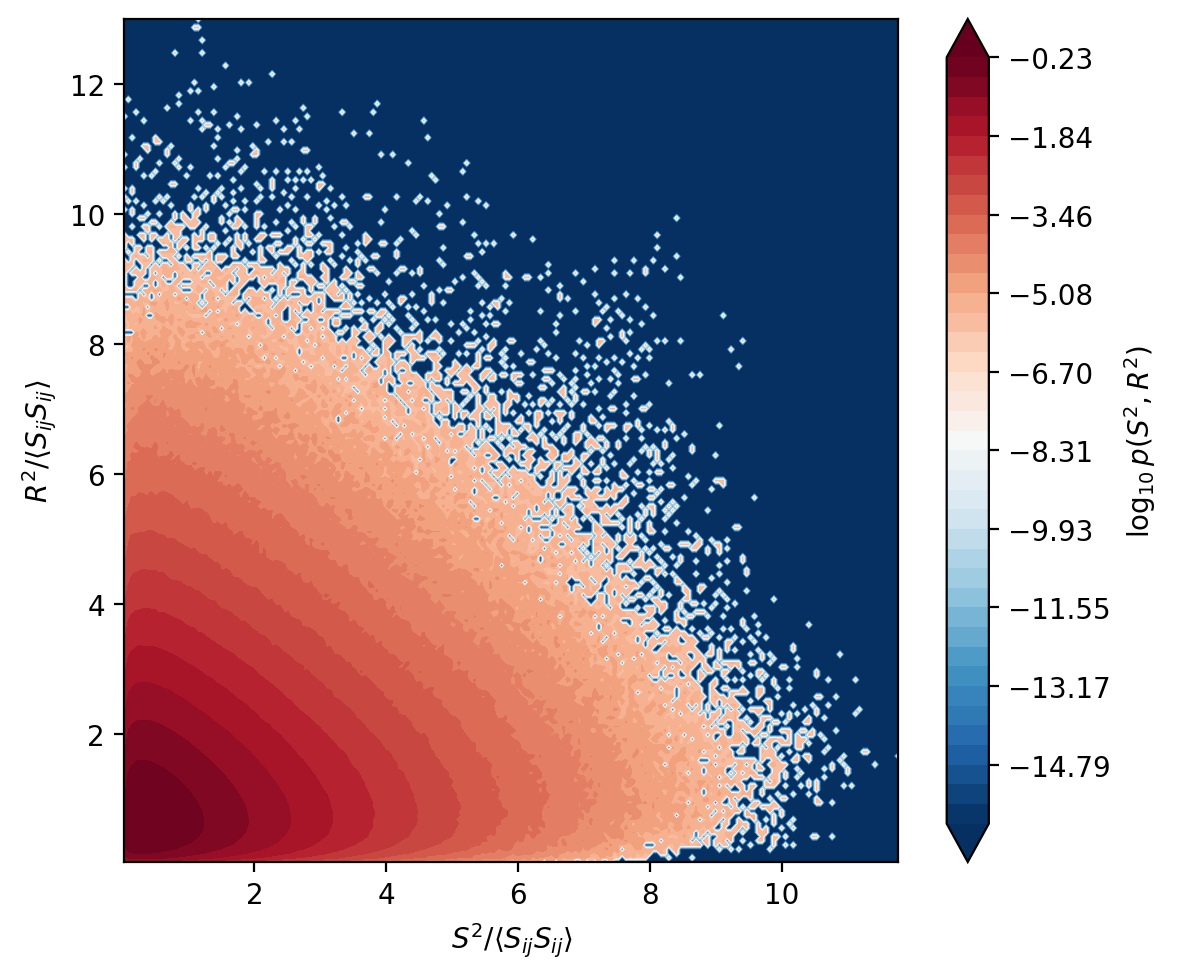

In [13]:
plt.figure(figsize=(6,5), dpi=200)

S2c = 0.5 * (S2edges[:-1] + S2edges[1:])
R2c = 0.5 * (R2edges[:-1] + R2edges[1:])

Z = np.log10(H.T + 1e-16)

levels = np.linspace(Z.min(), Z.max(), 40)

plt.contourf(S2c, R2c, Z.T, levels=levels,cmap='RdBu_r',extend='both')

plt.xlabel(r"$S^2/\langle S_{ij}S_{ij}\rangle$")
plt.ylabel(r"$R^2/\langle S_{ij}S_{ij}\rangle$")

plt.colorbar(label=r"$\log_{10} p(S^2,R^2)$")
plt.tight_layout()
plt.show()

In [15]:
# np.savez("S2R2_PDF_0p5.npz", bins_S2 = S2c, bins_R2 = R2c, PDF = H)

In [39]:
Qedges_0p0 = np.load('QR_Data/S2R2_PDF_0p0.npz')['bins_S2']
Redges_0p0= np.load('QR_Data/S2R2_PDF_0p0.npz')['bins_R2']
H_0p0 =  np.load('QR_Data/S2R2_PDF_0p0.npz')['PDF']


Qedges_0p1 = np.load('QR_Data/S2R2_PDF_0p1.npz')['bins_R2']
Redges_0p1 = np.load('QR_Data/S2R2_PDF_0p1.npz')['bins_R2']
H_0p1 =  np.load('QR_Data/S2R2_PDF_0p1.npz')['PDF']



Qedges_0p3 = np.load('QR_Data/S2R2_PDF_0p3.npz')['bins_R2']
Redges_0p3 = np.load('QR_Data/S2R2_PDF_0p3.npz')['bins_R2']
H_0p3=  np.load('QR_Data/S2R2_PDF_0p3.npz')['PDF']


Qedges_0p5 = np.load('QR_Data/S2R2_PDF_0p5.npz')['bins_R2']
Redges_0p5 = np.load('QR_Data/S2R2_PDF_0p5.npz')['bins_R2']
H_0p5 =  np.load('QR_Data/S2R2_PDF_0p5.npz')['PDF']


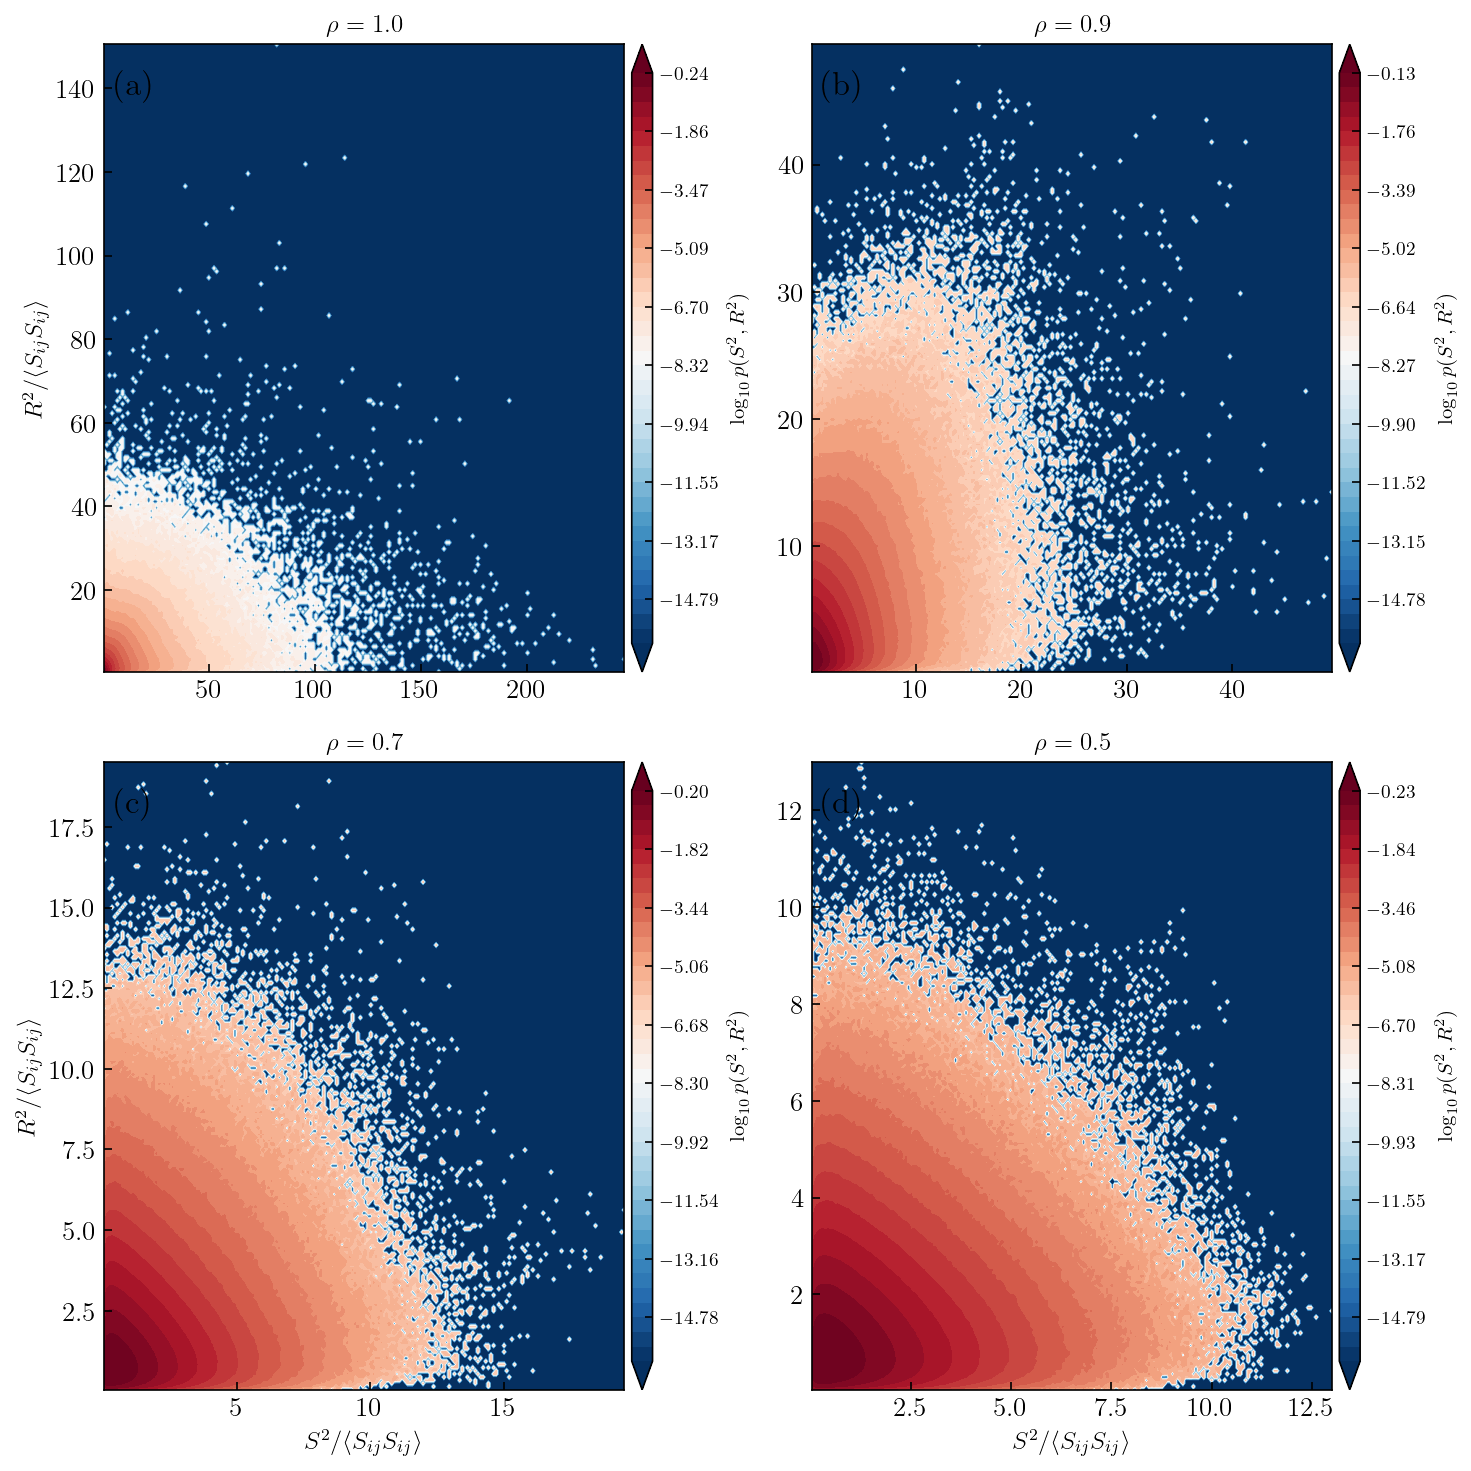

In [41]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=150)


Z0p0 = np.log10(H_0p0.T + 1e-16)
levels0p0 = np.linspace(Z0p0.min(), Z0p0.max(), 40)

# ---- main plot ----
cf = axes[0,0].contourf(
    Redges_0p0,Qedges_0p0, Z0p0.T,
    levels=levels0p0,
    cmap='RdBu_r',
    extend='both'
)

# ---- colorbar: clean & aligned ----
divider = make_axes_locatable(axes[0,0])

cax = divider.append_axes("right", size="4%", pad=0.05)
cbar = fig.colorbar(cf, cax=cax)
cbar.ax.tick_params(labelsize=9)
cbar.set_label(label=r"$\log_{10} p(S^2,R^2)$", fontsize=10)










Z0p1 = np.log10(H_0p1.T + 1e-16)
levels0p1 = np.linspace(Z0p1.min(), Z0p1.max(), 40)

# ---- main plot ----
cf = axes[0,1].contourf(
    Redges_0p1, Qedges_0p1, Z0p1.T,
    levels=levels0p1,
    cmap='RdBu_r',
    extend='both'
)

# ---- colorbar: clean & aligned ----
divider = make_axes_locatable(axes[0,1])

cax = divider.append_axes("right", size="4%", pad=0.05)
cbar = fig.colorbar(cf, cax=cax)
cbar.ax.tick_params(labelsize=9)
cbar.set_label(label=r"$\log_{10} p(S^2,R^2)$", fontsize=10)










Z0p3 = np.log10(H_0p3.T + 1e-16)
levels0p3 = np.linspace(Z0p3.min(), Z0p3.max(), 40)

# ---- main plot ----
cf = axes[1,0].contourf(
    Redges_0p3,Qedges_0p3, Z0p3.T,
    levels=levels0p3,
    cmap='RdBu_r',
    extend='both'
)

# ---- colorbar: clean & aligned ----
divider = make_axes_locatable(axes[1,0])

cax = divider.append_axes("right", size="4%", pad=0.05)
cbar = fig.colorbar(cf, cax=cax)
cbar.ax.tick_params(labelsize=9)
cbar.set_label(label=r"$\log_{10} p(S^2,R^2)$", fontsize=10)













Z0p5 = np.log10(H_0p5.T + 1e-16)
levels0p5 = np.linspace(Z0p5.min(), Z0p5.max(), 40)

# ---- main plot ----
cf = axes[1,1].contourf(
    Redges_0p5, Qedges_0p5, Z0p5.T,
    levels=levels0p5,
    cmap='RdBu_r',
    extend='both'
)

# ---- colorbar: clean & aligned ----
divider = make_axes_locatable(axes[1,1])

cax = divider.append_axes("right", size="4%", pad=0.05)
cbar = fig.colorbar(cf, cax=cax)
cbar.ax.tick_params(labelsize=9)
cbar.set_label(label=r"$\log_{10} p(S^2,R^2)$", fontsize=10)




# ---- axis labels ----
for ax in axes[:, 0]:
    ax.set_ylabel(r"$R^2/\langle S_{ij}S_{ij}\rangle$", fontsize = 12)

for ax in axes[1, :]:
    ax.set_xlabel(r"$S^2/\langle S_{ij}S_{ij}\rangle$", fontsize = 12)


panel_labels = ['(a)', '(b)', '(c)', '(d)']

for ax, label in zip(axes.flat, panel_labels):
    ax.text(
        0.02, 0.96, label,
        transform=ax.transAxes,
        fontsize=16,
        va='top',
        ha='left'
    )


titles = [
    r"$\rho = 1.0$", r"$\rho = 0.9$",
    r"$\rho = 0.7$", r"$\rho = 0.5$"
]

for ax, title in zip(axes.flat, titles):
    ax.set_title(title, fontsize=12, pad=6)


plt.tight_layout()

plt.savefig("100_percentile_S2R2_init_plot.png", dpi = 300)
plt.show()

